In [ ]:
# Import data tools
import pandas as pd
import numpy as np

# Import visualisation tools
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("../data/loan_default_dataset_noisy.csv")

df.head()

,CustomerID,Age,Gender,Marital_Status,Education,Employment_Type,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Income_Loan_Ratio,Loan_Status
0,1000,59,Male,Single,Not Graduate,Salaried,11082,3363,284.0,120,1.0,Semiurban,0.508627,Y
1,1001,49,NaN,Married,Graduate,Salaried,10822,3524,164.0,360,0.0,Semiurban,0.874756,Y
2,1002,35,Male,Married,Graduate,Salaried,3986,3786,414.0,240,1.0,Semiurban,0.187729,N
3,1003,63,Male,Single,Not Graduate,Salaried,10526,23,139.0,300,1.0,Rural,0.758921,Y
4,1004,28,Female,Married,Graduate,Salaried,9918,3003,257.0,240,0.0,Urban,0.502763,N


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2100 non-null   int64  
 1   Age                2100 non-null   int64  
 2   Gender             1995 non-null   str    
 3   Marital_Status     1993 non-null   str    
 4   Education          2100 non-null   str    
 5   Employment_Type    2100 non-null   str    
 6   ApplicantIncome    2100 non-null   int64  
 7   CoapplicantIncome  2100 non-null   int64  
 8   LoanAmount         1994 non-null   float64
 9   Loan_Amount_Term   2100 non-null   int64  
 10  Credit_History     1993 non-null   float64
 11  Property_Area      2100 non-null   str    
 12  Income_Loan_Ratio  2100 non-null   float64
 13  Loan_Status        2100 non-null   str    
dtypes: float64(3), int64(5), str(6)
memory usage: 229.8 KB


In [ ]:
df.describe()

,CustomerID,Age,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Income_Loan_Ratio
count,2100.000000,2100.000000,2100.000000,2100.000000,1994.000000,2100.000000,1993.000000,2100.000000
mean,2001.513810,42.670000,8290.765238,4049.764762,270.344534,240.571429,0.792775,0.640285
std,578.359094,12.603574,3912.710716,2288.544407,128.411200,85.535374,0.405420,0.547168
min,1000.000000,21.000000,1512.000000,2.000000,50.000000,120.000000,0.000000,0.047368
25%,1499.750000,32.000000,4910.750000,2067.250000,158.250000,180.000000,1.000000,0.297800
50%,2002.500000,43.000000,8367.500000,4050.500000,271.000000,240.000000,1.000000,0.457574
75%,2503.250000,54.000000,11666.000000,6001.250000,379.000000,300.000000,1.000000,0.772765
max,2999.000000,64.000000,14999.000000,7999.000000,499.000000,360.000000,1.000000,4.034510


In [ ]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender               105
Marital_Status       107
Education              0
Employment_Type        0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount           106
Loan_Amount_Term       0
Credit_History       107
Property_Area          0
Income_Loan_Ratio      0
Loan_Status            0
dtype: int64

In [ ]:
df.duplicated().sum()

100

In [ ]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2000 non-null   int64  
 1   Age                2000 non-null   int64  
 2   Gender             1900 non-null   str    
 3   Marital_Status     1900 non-null   str    
 4   Education          2000 non-null   str    
 5   Employment_Type    2000 non-null   str    
 6   ApplicantIncome    2000 non-null   int64  
 7   CoapplicantIncome  2000 non-null   int64  
 8   LoanAmount         1900 non-null   float64
 9   Loan_Amount_Term   2000 non-null   int64  
 10  Credit_History     1900 non-null   float64
 11  Property_Area      2000 non-null   str    
 12  Income_Loan_Ratio  2000 non-null   float64
 13  Loan_Status        2000 non-null   str    
dtypes: float64(3), int64(5), str(6)
memory usage: 218.9 KB


In [ ]:
# Checking for duplicates again after removal
df.duplicated().sum()

0

In [ ]:
# Create total income
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

# Create loan-to-income ratio
df["Loan_Income_Ratio"] = df["LoanAmount"] / df["Total_Income"]

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2000 non-null   int64  
 1   Age                2000 non-null   int64  
 2   Gender             1900 non-null   str    
 3   Marital_Status     1900 non-null   str    
 4   Education          2000 non-null   str    
 5   Employment_Type    2000 non-null   str    
 6   ApplicantIncome    2000 non-null   int64  
 7   CoapplicantIncome  2000 non-null   int64  
 8   LoanAmount         1900 non-null   float64
 9   Loan_Amount_Term   2000 non-null   int64  
 10  Credit_History     1900 non-null   float64
 11  Property_Area      2000 non-null   str    
 12  Income_Loan_Ratio  2000 non-null   float64
 13  Loan_Status        2000 non-null   str    
 14  Total_Income       2000 non-null   int64  
 15  Loan_Income_Ratio  1900 non-null   float64
dtypes: float64(4), int64(6), str(6)
mem

In [ ]:
# Step 0: Fix column names
df.columns = df.columns.str.strip()

# Step 1: Identify text columns (future-proof)
text_columns = df.select_dtypes(include=["object", "string"]).columns

# Step 2: Clean safely
for col in text_columns:
    df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)

# Step 3: Convert selected columns to title case
cols_to_title = ["Gender", "Marital_Status", "Education", "Employment_Type", "Property_Area"]

for col in cols_to_title:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x)

In [ ]:
df["Gender"].value_counts()

Gender
Female    960
Male      940
Name: count, dtype: int64

In [ ]:
df.to_csv("../data/cleaned_data/cleaned_loan_data.csv", index=False)

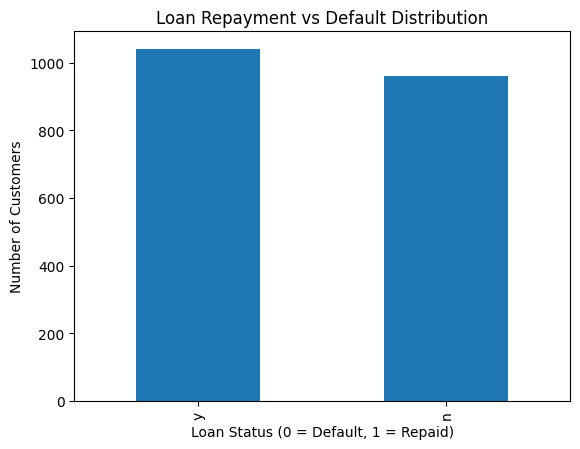

In [ ]:
# Chart 1 — Loan Default Distribution

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Repayment vs Default Distribution")
plt.xlabel("Loan Status (0 = Default, 1 = Repaid)")
plt.ylabel("Number of Customers")

plt.show()

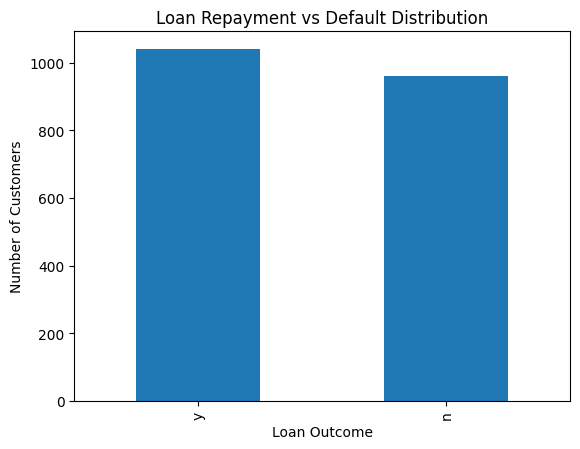

In [ ]:
df["Loan_Status"].value_counts().rename({
    0: "Defaulted",
    1: "Repaid"
}).plot(kind="bar")

plt.title("Loan Repayment vs Default Distribution")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Customers")

plt.show()

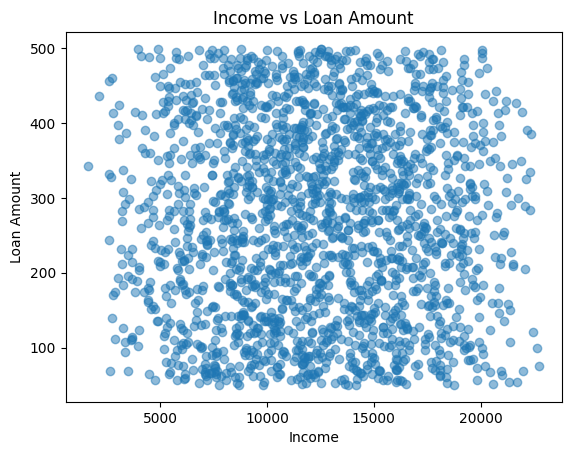

In [ ]:
plt.scatter(df["Total_Income"], df["LoanAmount"], alpha=0.5)

plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()

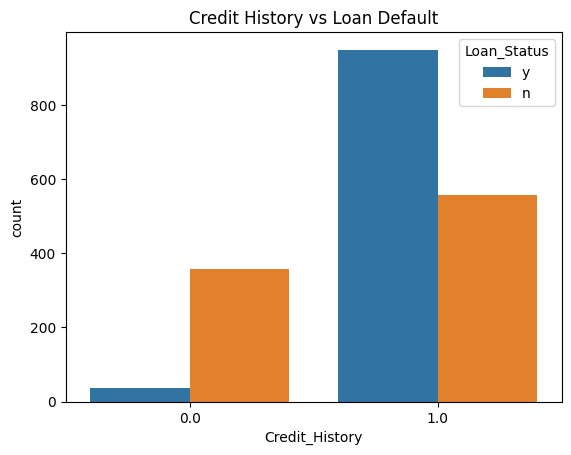

In [ ]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)

plt.title("Credit History vs Loan Default")

plt.show()


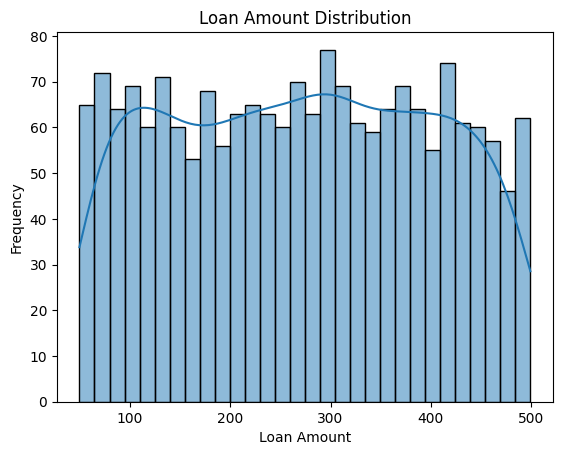

In [ ]:
import matplotlib.pyplot as plt

sns.histplot(df["LoanAmount"], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

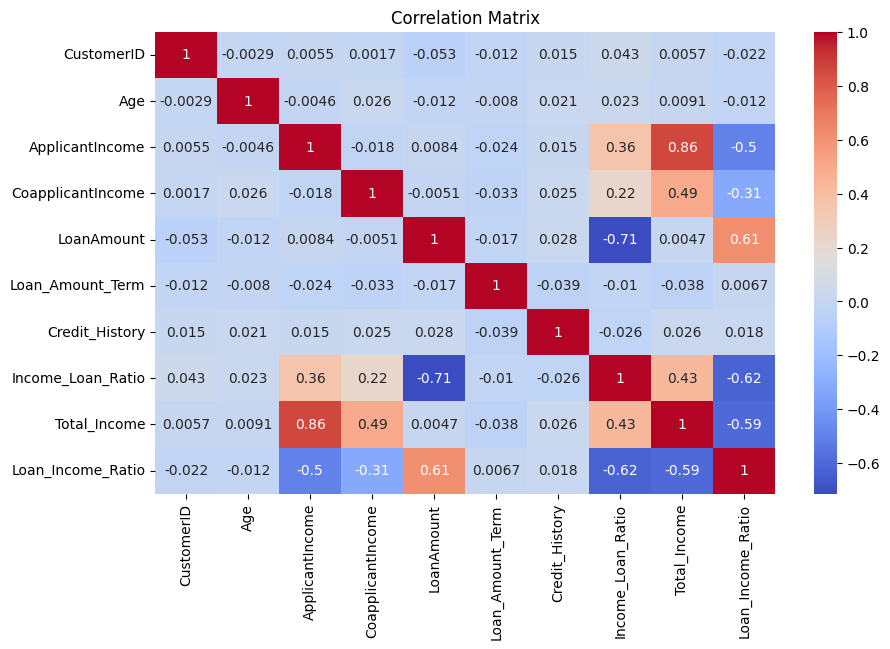

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
df["Risk_Level"] = pd.cut(
    df["Loan_Income_Ratio"],
    bins=[0, 0.02, 0.05, 1],
    labels=["Low", "Medium", "High"]
)

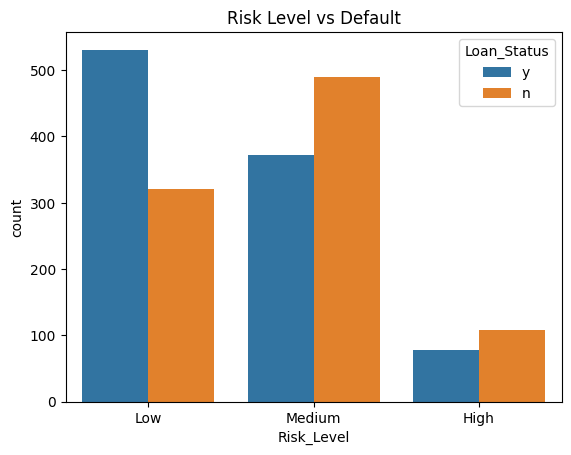

In [ ]:
sns.countplot(x="Risk_Level", hue="Loan_Status", data=df)

plt.title("Risk Level vs Default")

plt.show()

In [ ]:
# Save the final cleaned and feature-engineered dataset
df.to_csv("../data/cleaned_data/final_loan_data.csv", index=False)  